In [1]:
### Importing the required library 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import MolStandardize
import joblib

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors,rdMolDescriptors
import utilities


In [2]:
### Installation of the basic library 
from rdkit import Chem,DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import numpy as np

In [3]:
### Reading the preprocess data from disk 
### Train data 
train_set=pd.read_csv('../data/final_data/final_unique_train.csv')

### test data 
test_set=pd.read_csv('../data/final_data/final_unique_test.csv')

print(train_set.shape)
print(test_set.shape)

(17937, 8)
(1282, 8)


In [4]:
### Making smiles to list 
train_smiles_list=train_set[['smiles_canon']]
test_smiles_list=test_set[['smiles_canon']]

In [5]:

### Importing the function of the utility file to generate the descriptors and others evaluation matrics...  
import utilities

In [6]:
### Generate 4 descriptors ....
df4_train=utilities.generate4(train_set.smiles_canon)
df4_test=utilities.generate4(test_set.smiles_canon)
### Generate 17 descriptors ....
df17_train=utilities.generate17(train_set.smiles_canon)
df17_test=utilities.generate17(test_set.smiles_canon)
### Generate 123 descriptors ....
df123_train=utilities.generate123(train_set.smiles_canon)
df123_test=utilities.generate123(test_set.smiles_canon)
### Generate 38 feature engineered based on the structure of the smiles ....
df38_train=utilities.generate_features38(train_set.smiles_canon)
df38_test=utilities.generate_features38(test_set.smiles_canon)
### Generate 7 funnctional groups
df7_train=utilities.get_functional_groups(train_set.smiles_canon)
df7_test=utilities.get_functional_groups(test_set.smiles_canon)
### Fingerprint 128....
df128_train=utilities.fingerprint(train_set.smiles_canon,2,128)
df128_test=utilities.fingerprint(test_set.smiles_canon,2,128)
### Fingerprint 256....
df256_train=utilities.fingerprint(train_set.smiles_canon,2,256)
df256_test=utilities.fingerprint(test_set.smiles_canon,2,256)
### Fingerprint 512....
df512_train=utilities.fingerprint(train_set.smiles_canon,2,512)
df512_test=utilities.fingerprint(test_set.smiles_canon,2,512)
### Fingerprint 1024....
df1024_train=utilities.fingerprint(train_set.smiles_canon,2,1024)
df1024_test=utilities.fingerprint(test_set.smiles_canon,2,1024)

In [7]:
### Taking out the solubility data  
y_train=train_set.copy()['LogS']
y_test=test_set.copy()['LogS']

In [8]:
### Importing library to evaluate the best model 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgboost
from xgboost import XGBRegressor


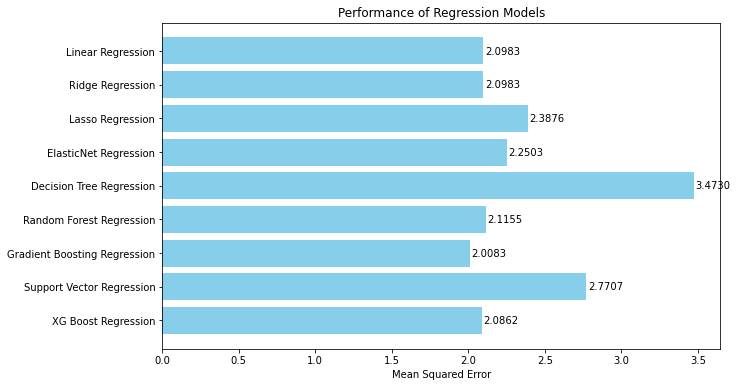

In [9]:
### Function to evaluate the Regresoor model 
def evaluate_model(X, y, model):
    """
    Evaluate a regression model using cross-validation and calculate the mean squared error.
    
    Parameters:
    - X: Feature matrix (DataFrame or array-like)
    - y: Target vector (Series or array-like)
    - model: Regression model object
    
    Returns:
    - Mean squared error (float)
    """
    cv_results = cross_validate(model, X, y, cv=10, scoring='neg_mean_squared_error')
    mse = -np.mean(cv_results['test_score'])
    return mse

# Extract feature matrix X and target vector y from the dataset
X = df4_train  ### descriptors 
y = y_train ### solubility values in LogS 

# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet Regression': ElasticNet(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'Support Vector Regression': SVR(),
     'XG Boost Regression': XGBRegressor()
}

# Evaluate each model and store the results
results = {}
for model_name, model in models.items():
    mse = evaluate_model(X, y, model)
    results[model_name] = mse

# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Mean Squared Error'])
results_df.index.name = 'Model'

# Save results to a CSV file
#results_df.to_csv('regression_model_comparison.csv')


plt.figure(figsize=(10, 6))
bars = plt.barh(results_df.index, results_df['Mean Squared Error'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Performance of Regression Models')

# Add annotations for each bar
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.4f}', 
             va='center', ha='left', color='black')

plt.gca().invert_yaxis()  # Invert y-axis to show the best model on top
plt.show()

In [10]:
### Importing the required library 
import xgboost #as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

In [11]:
### Importing the required library for evalaution metrics 
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

In [12]:
def get_errors1(y_true, y_pred, model_name="Model"):   
    err_mae = round(mae(y_true, y_pred), 4)
    err_rmse = round(np.sqrt(mse(y_true, y_pred)), 4)
    err_r2 = round(r2_score(y_true, y_pred), 4)
    err_mse = round(mse(y_true, y_pred), 4)
        
    results = np.column_stack([model_name, err_mae, err_mse, err_rmse, err_r2])
    df_results = pd.DataFrame(results, columns=['Model_Name', 'MAE', 'MSE', 'RMSE', 'R2'])
    return df_results

In [13]:
### Running the model for basic 4 descriptirs ....
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
xgboost_model.fit(df4_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df4_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_4=get_errors1(y_test,pred_xgb,"XGB_4")


In [14]:
### Addinng the features details...
xgb_4['Descriptors_Detail']='4 features'

In [15]:
xgb_4

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_4,0.5672,0.5318,0.7292,0.8725,4 features


In [16]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)

### Fitting the model on train data 
xgboost_model.fit(df17_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df17_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_17=get_errors1(y_test,pred_xgb,"XGB_17")

In [17]:
xgb_17['Descriptors_Detail']='17 features'

In [18]:
xgb_17

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_17,0.4481,0.3464,0.5886,0.9169,17 features


In [19]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)### 
### Fitting the model on train data 
xgboost_model.fit(df123_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df123_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_125=get_errors1(y_test,pred_xgb,"XGB_125")

In [20]:
xgb_125['Descriptors_Detail']='125 features'

In [21]:
xgb_125

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_125,0.4098,0.3092,0.5561,0.9259,125 features


In [22]:
### 125 descriptors  and 128 fingerprint  
df253_train=pd.concat([df123_train, df128_train], axis=1)
df253_test=pd.concat([df123_test, df128_test], axis=1)

In [23]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)### 
### Fitting the model on train data 
xgboost_model.fit(df253_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df253_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_253=get_errors1(y_test,pred_xgb,"XGB_253")

In [24]:
xgb_253['Descriptors_Detail']='125 features + 128 fingerprint'

In [25]:
xgb_253

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_253,0.4078,0.3073,0.5544,0.9263,125 features + 128 fingerprint


In [41]:
### 125 and 128 fingerprint + 7 functional group   
df260_train=pd.concat([df253_train, df7_train], axis=1)
df260_test=pd.concat([df253_test, df7_test], axis=1)

In [42]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df260_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df260_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_260=get_errors1(y_test,pred_xgb,"XGB_260")

In [43]:
xgb_260['Descriptors_Detail']='125 features + 128 fingerprint 7 f_group'

In [44]:
xgb_260

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_260,0.4081,0.3071,0.5542,0.9264,125 features + 128 fingerprint 7 f_group


In [45]:
### 125 + 128 fp and 7 functional group + 38 featured engineered total (
df298_train=pd.concat([df260_train, df38_train], axis=1)
df298_test=pd.concat([df260_test, df38_test], axis=1)

In [46]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df298_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df298_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_298=get_errors1(y_test,pred_xgb,"XGB_298")

In [47]:
xgb_298['Descriptors_Detail']='125 features + 128 fingerprint 7 f_group+38 fe features'

In [48]:
xgb_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_298,0.4045,0.3036,0.551,0.9272,125 features + 128 fingerprint 7 f_group+38 fe...


In [35]:
## Remove nan and infinity values from the dataset
df_train2 = pd.concat([df298_train, y_train], axis=1)
df_test2 = pd.concat([df298_test, y_test], axis=1)
df_train = df_train2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
df_test = df_test2.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_train = df_train.iloc[:, :-1]  # All columns except the last one
y_train = df_train.iloc[:, -1] 
X_test = df_test.iloc[:, :-1]  # All columns except the last one
y_test = df_test.iloc[:, -1] 

In [36]:
X_train = df_train.iloc[:, :-1]  # All columns except the last one
y_train = df_train.iloc[:, -1] 
X_test = df_test.iloc[:, :-1]  # All columns except the last one
y_test = df_test.iloc[:, -1] 

In [57]:
### saving the model to the disk 
#import xgboost as xgb
#xgboost_model.save_model('data/xgboost_model_298_4045.json')

In [37]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=1000,          # Number of trees
    max_depth=10,              # Maximum depth of each tree
    min_samples_split=2,       # Minimum samples required to split an internal node
    min_samples_leaf=1,        # Minimum samples required to be at a leaf node
    max_features='auto',       # Number of features to consider when looking for the best split
    random_state=42            # Random state for reproducibility
)
### Fitting the model on train data 
rf.fit(X_train,y_train)    
### Predicting on test data 
pred_rf = rf.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
rf_298=get_errors1(y_test,pred_rf,"rf_298")

In [39]:
rf_298['Descriptors_Detail']='125_features + 128_fp , 7_f_group+ 38 fe_features+'

In [40]:
rf_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,rf_298,0.5,0.4148,0.6441,0.9005,"125_features + 128_fp , 7_f_group+ 38 fe_featu..."


In [49]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    n_estimators=1000,         # Number of boosting stages to be run
    learning_rate=0.01,        # Learning rate shrinks the contribution of each tree
    max_depth=8,               # Maximum depth of the individual estimators
    min_samples_split=2,       # Minimum number of samples required to split an internal node
    min_samples_leaf=1,        # Minimum number of samples required to be at a leaf node
    max_features=None,         # Number of features to consider when looking for the best split
    random_state=42            # Random state for reproducibility
)
### Fitting the model on train data 
gb.fit(X_train,y_train)    
### Predicting on test data 
pred_gb = gb.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
gb_298=get_errors1(y_test,pred_gb,"gb_298")

In [50]:
gb_298['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+128_fp'

In [51]:
gb_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,gb_298,0.4284,0.3298,0.5742,0.9209,125_features + 7_f_group+38 fe_features+128_fp


In [52]:
### Importing required library 
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [54]:
### To train Nezral network 
model = Sequential()
model.add(Dense(512, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32)#, validation_split=0.2)
pred_nn = model.predict(X_test)
### Calculating the evaluation matrix MAE , RMSE and R2
nn_298=get_errors1(y_test,pred_nn,"nn_298")


2025-04-09 13:17:07.304902: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-04-09 13:17:07.306043: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-09 13:17:07.441180: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Epoch 1/100
561/561 [==============================] - 2s 2ms/step - loss: 2.4939
Epoch 2/100
561/561 [==============================] - 1s 2ms/step - loss: 1.1889
Epoch 3/100
561/561 [==============================] - 1s 2ms/step - loss: 1.1381
Epoch 4/100
561/561 [==============================] - 1s 2ms/step - loss: 1.0906
Epoch 5/100
561/561 [==============================] - 1s 2ms/step - loss: 1.0019
Epoch 6/100
561/561 [==============================] - 1s 2ms/step - loss: 0.9044
Epoch 7/100
561/561 [==============================] - 1s 2ms/step - loss: 0.8744
Epoch 8/100
561/561 [==============================] - 1s 2ms/step - loss: 0.8181
Epoch 9/100
561/561 [==============================] - 1s 2ms/step - loss: 0.7720
Epoch 10/100
561/561 [==============================] - 1s 2ms/step - loss: 0.8307
Epoch 11/100
561/561 [==============================] - 1s 2ms/step - loss: 0.7629
Epoch 12/100
561/561 [==============================] - 1s 2ms/step - loss: 0.6929
Epoch 13/100


In [55]:
nn_298['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+128_fp'

In [56]:
nn_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,nn_298,0.5196,0.5086,0.7132,0.878,125_features + 7_f_group+38 fe_features+128_fp


In [58]:
### 125 + 128 fp and 7 functional group + 38 featured engineered total (
df163_train=pd.concat([df123_train, df38_train], axis=1)
df163_test=pd.concat([df123_test, df38_test], axis=1)

In [59]:
df170_train=pd.concat([df163_train, df7_train], axis=1)
df170_test=pd.concat([df163_test, df7_test], axis=1)

In [60]:
### Adding the 256 fingerprint with  features and funtional group
df426_train=pd.concat([df170_train, df256_train], axis=1)
df426_test=pd.concat([df170_test, df256_test], axis=1)

In [64]:
df682_train=pd.concat([df170_train, df512_train], axis=1)
df682_test=pd.concat([df170_test, df512_test], axis=1)

In [65]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df682_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df682_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_682=get_errors1(y_test,pred_xgb,"XGB_682")

In [66]:
xgb_682['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+512_fp'

In [67]:
xgb_682

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_682,0.4106,0.3083,0.5552,0.9261,125_features + 7_f_group+38 fe_features+512_fp


In [68]:
df1194_train=pd.concat([df170_train, df1024_train], axis=1)
df1194_test=pd.concat([df170_test, df1024_test], axis=1)

In [69]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df1194_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df1194_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_1194=get_errors1(y_test,pred_xgb,"XGB_1194")

In [70]:
xgb_1194['Descriptors_Detail']='125_features + 7_f_group+38 fe_features+1024_fp'

In [71]:
xgb_1194

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_1194,0.4183,0.3148,0.5611,0.9245,125_features + 7_f_group+38 fe_features+1024_fp


In [73]:
from sklearn.feature_selection import SelectFromModel

In [74]:
from sklearn.linear_model import Lasso
def select_features_lasso(train_data,test_data):
    """
    Selects descriptors from training data then applies on both training and test data 
    """
    
    lasso = Lasso(alpha=0.01,max_iter=10000,random_state=1).fit(train_data.drop(columns=['LogS']), train_data['LogS'])
    model = SelectFromModel(lasso, prefit=True)
    X_new_lasso = model.transform(train_data.drop(columns=['LogS']))
    # Get back the kept features as a DataFrame with dropped columns as all 0s
    selected_features = pd.DataFrame(model.inverse_transform(X_new_lasso), index=train_data.drop(columns=['LogS']).index, columns=train_data.drop(columns=['LogS']).columns)
    # Dropped columns have values of all 0s, keep other columns 
    selected_columns_lasso = selected_features.columns[selected_features.var() != 0]
    
    selected_data_train = train_data[selected_columns_lasso]             
    selected_data_test = test_data[selected_columns_lasso]
    selected_data_test = selected_data_test.apply(pd.to_numeric)
    
    print(selected_data_train.columns)
    print("Total selected descriptors by LASSO:",len(selected_data_train.columns))
      
    return selected_data_train, selected_data_test


In [75]:
X_train13=pd.concat([df298_train, y_train], axis=1)
X_test13=pd.concat([df298_test, y_test], axis=1)

In [76]:
y_train1=y_train.copy()
y_test1=y_test.copy()

In [77]:
X_train14=X_train13.copy()
X_test14=X_test13.copy()

In [78]:
### Removing the NAN and infinitive values from the dataset 
X_train14 = X_train14.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
X_tetst14 = X_test14.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
y_train1 = y_train1.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
y_test1 = y_test1.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)

In [79]:
### Selecting the important features with Lasso technique ...
selected_data_train, selected_data_test = select_features_lasso(X_train14,X_test14)


Index([                'MaxEStateIndex',                 'MinEStateIndex',
                                  'SPS',                 'HeavyAtomMolWt',
                  'NumValenceElectrons',               'FpDensityMorgan1',
                          'BCUT2D_MWHI',                   'BCUT2D_MWLOW',
                          'BCUT2D_MRHI',                       'BalabanJ',
       ...
                               'Alkene',                 'atoms_degree_1',
                       'atoms_degree_2',                 'atoms_degree_3',
                       'atoms_degree_4',                'atoms_valence_2',
                      'atoms_valence_5',         'atom_hybridization_SP2',
       'atom_hybridization_UNSPECIFIED',               'conjugated_bonds'],
      dtype='object', length=115)
Total selected descriptors by LASSO: 115


In [81]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)

xgboost_model.fit(selected_data_train,y_train1)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(selected_data_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_115=get_errors1(y_test1,pred_xgb,"XGB_115")

In [83]:
xgb_115['Descriptors_Detail']='115 features_by_LASSO'

In [84]:
xgb_115

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_115,0.4226,0.33,0.5745,0.9209,115 features_by_LASSO


In [87]:
#### Calculating descriptors which used by Sorkun a Reference paper -...
import pandas as pd
from rdkit import Chem
from mordred import Calculator, descriptors

def get_mordred(mol, desc_names=False):
    """
    Generates predefined descriptors for a given RDKit mol object.
    
    Parameters:
    mol (RDKit Mol object): The molecule for which descriptors are to be calculated.
    desc_names (bool): If True, returns only the list of descriptor names.

    Returns:
    list: List of descriptor values if desc_names is False.
    list: List of descriptor names if desc_names is True.
    """
    # Initialize the Mordred calculator
    calc = Calculator()

    # Registering specific descriptors
    calc.register(descriptors.AtomCount.AtomCount("X"))
    calc.register(descriptors.AtomCount.AtomCount("HeavyAtom"))
    calc.register(descriptors.Aromatic.AromaticAtomsCount)
    calc.register(descriptors.HydrogenBond.HBondAcceptor)
    calc.register(descriptors.HydrogenBond.HBondDonor)
    calc.register(descriptors.RotatableBond.RotatableBondsCount)
    calc.register(descriptors.BondCount.BondCount("any", False))
    calc.register(descriptors.Aromatic.AromaticBondsCount)
    calc.register(descriptors.BondCount.BondCount("heavy", False))
    calc.register(descriptors.BondCount.BondCount("single", False))
    calc.register(descriptors.BondCount.BondCount("double", False))
    calc.register(descriptors.BondCount.BondCount("triple", False))
    calc.register(descriptors.McGowanVolume.McGowanVolume)
    calc.register(descriptors.TopoPSA.TopoPSA(True))
    calc.register(descriptors.TopoPSA.TopoPSA(False))
    calc.register(descriptors.MoeType.LabuteASA)
    calc.register(descriptors.Polarizability.APol)
    calc.register(descriptors.Polarizability.BPol)
    calc.register(descriptors.AcidBase.AcidicGroupCount)
    calc.register(descriptors.AcidBase.BasicGroupCount)
    calc.register(descriptors.EccentricConnectivityIndex.EccentricConnectivityIndex)
    calc.register(descriptors.TopologicalCharge.TopologicalCharge("raw", 1))
    calc.register(descriptors.TopologicalCharge.TopologicalCharge("mean", 1))
    calc.register(descriptors.SLogP)
    calc.register(descriptors.BertzCT.BertzCT)
    calc.register(descriptors.BalabanJ.BalabanJ)
    calc.register(descriptors.WienerIndex.WienerIndex(True))
    calc.register(descriptors.ZagrebIndex.ZagrebIndex(1, 1))
    calc.register(descriptors.ABCIndex)
    calc.register(descriptors.RingCount.RingCount(None, False, False, None, None))
    calc.register(descriptors.RingCount.RingCount(None, False, False, None, True))
    calc.register(descriptors.RingCount.RingCount(None, False, False, True, None))
    calc.register(descriptors.RingCount.RingCount(None, False, False, True, True))
    calc.register(descriptors.RingCount.RingCount(None, False, False, False, None))
    calc.register(descriptors.RingCount.RingCount(None, False, True, None, None))
    calc.register(descriptors.EState)

    # If desc_names is True, return the list of descriptor names
    if desc_names:
        return [str(desc) for desc in calc.descriptors]
    else:
        # Compute descriptors for the given molecule
        result = calc(mol)
        return result._values

def calculate_element_counts(mol, elements):
    """
    Calculate the count of specified elements in the molecule.

    Parameters:
    mol (RDKit Mol object): The molecule.
    elements (list): List of element symbols to count.

    Returns:
    dict: Dictionary with element counts.
    """
    element_counts = {el: 0 for el in elements}
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in element_counts:
            element_counts[symbol] += 1
    return element_counts

def generate_descriptors_from_smiles_list(smiles_list):
    """
    Generate molecular descriptors from a list of SMILES strings.
    
    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    pd.DataFrame: DataFrame of descriptor values for all SMILES.
    """
    all_descriptors = []
    elements = ['C', 'H', 'Br', 'N', 'O', 'I', 'Cl', 'S', 'F', 'P', 'As', 'Si', 'Se', 'Sn', 'Hg', 'Ge']
    
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")
        
        # Get the descriptor names and values
        descriptor_names = get_mordred(mol, desc_names=True)
        descriptor_values = get_mordred(mol, desc_names=False)
        
        # Calculate element counts
        element_counts = calculate_element_counts(mol, elements)
        
        # Combine descriptors and element counts
        combined_descriptors = descriptor_values + list(element_counts.values())
        
        all_descriptors.append(combined_descriptors)
    
    # Create the DataFrame
    columns = descriptor_names + elements
    df = pd.DataFrame(all_descriptors, columns=columns)
    return df

In [88]:
smiles_list_train=train_set['smiles_canon'].tolist()
smiles_list_test=test_set['smiles_canon'].tolist()
descriptor_df_train = generate_descriptors_from_smiles_list(smiles_list_train)
descriptor_df_test = generate_descriptors_from_smiles_list(smiles_list_test)
# List of columns to select
columns_to_select = ['nX', 'nHeavyAtom', 'nAromAtom', 'nHBAcc', 'nHBDon', 'nRot', 'nBonds', 'nAromBond', 'nBondsO', 'nBondsS', 'nBondsD', 'nBondsT', 
'VMcGowan', 'TopoPSA(NO)', 'TopoPSA', 'LabuteASA', 'apol', 'bpol', 'nAcid', 'nBase', 'ECIndex', 'GGI1', 'JGI1', 'SLogP', 'SMR', 
'BertzCT', 'BalabanJ', 'WPol', 'Zagreb1', 'ABC', 'ABCGG', 'nRing', 'nHRing', 'naRing', 'naHRing', 'nARing', 'nFRing', 
'NsCH3', 'NdCH2', 'NssCH2', 'NtCH', 'NdsCH', 'NaaCH', 'NsssCH', 'NddC', 'NtsC', 'NdssC', 'NaasC', 'NaaaC', 'NssssC', 'NsNH2', 'NssNH', 
'NaaNH', 'NtN', 'NdsN', 'NaaN', 'NsssN', 'NaasN', 'NsOH', 'NdO', 'NssO', 'NaaO', 'NsF', 'NdsssP', 'NdS', 'NssS', 'NaaS', 'NdssS', 
'NddssS', 'NsCl', 'NsBr', 'NsI', 'SsCH3', 'SdCH2', 'SssCH2', 'StCH', 'SdsCH', 'SaaCH', 'SsssCH', 'SddC', 'StsC', 'SdssC', 'SaasC',
 'SaaaC', 'SssssC', 'SsNH2', 'SssNH', 'SaaNH', 'StN', 'SdsN', 'SaaN', 'SsssN', 'SaasN', 'SsOH', 'SdO', 'SssO', 'SaaO', 'SsF', 
 'SdsssP', 'SdS', 'SssS', 'SaaS', 'SdssS', 'SddssS', 'SsCl', 'SsBr', 'SsI', 'C', 'H', 'Br', 'N', 'O', 'I', 'Cl', 'S', 'F', 'P', 'As', 'Si', 'Se', 'Sn', 'Hg', 'Ge']

# Create a new DataFrame with selected columns
df_train = descriptor_df_train[columns_to_select]
df_test = descriptor_df_test[columns_to_select]


In [89]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
                                           
## Fitting the model on train data 
xgboost_model.fit(df_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df_test)
### Calculating the evaluation matrix MAE , RMSE and R2
sorkun_123=get_errors1(y_test,pred_xgb,"Sorkun_123")

In [90]:
sorkun_123['Descriptors_Detail']='123 features used in the sorkuns works'

In [91]:
sorkun_123

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,Sorkun_123,0.4255,0.3153,0.5615,0.9244,123 features used in the sorkuns works


In [94]:
### MPNN result from mpnn.ipynb file 
import pandas as pd

# Define the data
data = {
    "Model_Name": ["Graph based model"],
    "MAE": [0.6835],
    "MSE": [0.8322],
    "RMSE": [0.7635],
    "R2": [0.8223],
    "Descriptors_Detail": ["Message Passing Neural Network (MPNN)"]
}

# Create the DataFrame
mpnn_2l = pd.DataFrame(data)

# Display the DataFrame
mpnn_2l


,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,Graph based model,0.6835,0.8322,0.7635,0.8223,Message Passing Neural Network (MPNN)


In [101]:
### Hybrid_MPNN result from mpnn_Hybrid.ipynb file 
import pandas as pd

# Define the data
data = {
    "Model_Name": ["Graph based model"],
    "MAE": [0.4618],
    "MSE": [0.7622],
    "RMSE": [0.6366],
    "R2": [0.9028],
    "Descriptors_Detail": ["Hybrid-Message Passing Neural Network (MPNN)"]
}

# Create the DataFrame
hybridd_mpnn = pd.DataFrame(data)



In [102]:
combined_df=pd.concat([xgb_4,xgb_17,xgb_125,sorkun_123,xgb_253,xgb_260,xgb_298,rf_298,gb_298,nn_298,mpnn_2l,hybridd_mpnn,xgb_426,xgb_682,xgb_1194],axis=0)

In [103]:
combined_df.index = pd.RangeIndex(start=1, stop=len(combined_df) + 1, step=1)
combined_df


,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
1,XGB_4,0.5672,0.5318,0.7292,0.8725,4 features
2,XGB_17,0.4481,0.3464,0.5886,0.9169,17 features
3,XGB_125,0.4098,0.3092,0.5561,0.9259,125 features
4,Sorkun_123,0.4255,0.3153,0.5615,0.9244,123 features used in the sorkuns works
5,XGB_253,0.4078,0.3073,0.5544,0.9263,125 features + 128 fingerprint
6,XGB_260,0.4081,0.3071,0.5542,0.9264,125 features + 128 fingerprint 7 f_group
7,XGB_298,0.4045,0.3036,0.551,0.9272,125 features + 128 fingerprint 7 f_group+38 fe...
8,rf_298,0.5,0.4148,0.6441,0.9005,"125_features + 128_fp , 7_f_group+ 38 fe_featu..."
9,gb_298,0.4284,0.3298,0.5742,0.9209,125_features + 7_f_group+38 fe_features+128_fp
10,nn_298,0.5196,0.5086,0.7132,0.878,125_features + 7_f_group+38 fe_features+128_fp


In [104]:
### End here 

In [96]:
## saving this result dataframe to file 
#combined_df.to_csv('data/model_results_new.csv')